# Non-responder analysis

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
  library(patchwork)
  library(cowplot)
})

In [ ]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [ ]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/cite_seq/cohort_nonresponders/annotated/annotated.qs", nthreads = getOption("hpc.ncpus", 1))

### Program scores

In [ ]:
gep.usage.discovery <- set_names(c("B", "DC", "Mono", "NK", "T")) %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`


In [ ]:
gep.usage.nonresponder <- set_names(c("T")) %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/cite_seq/cohort_nonresponders/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/cite_seq/cohort_nonresponders/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`


# Compute UMAP (project onto discovery cohort UMAP embedding)

In [ ]:
# Split object
obj.list <- SplitObject(object = seu, split.by = "orig.ident")

QS object generated by running notebooks in `03_annotate`

In [ ]:
# Load reference dataset and precompute neighbors
ref <- qs::qread(file = "../data/processed/cite_seq/cohort_treatment_naive/annotated/annotated.qs", nthreads = getOption("hpc.ncpus", 1)) %>% 
  FindNeighbors(
    reduction = "pca",
    dims = 1:50,
    graph.name = "annoy.neighbors",
    k.param = 50,
    cache.index = TRUE,
    return.neighbor = TRUE,
    l2.norm = TRUE
  )

In [ ]:
# Project UMAP embedding from reference to query dataset
anchors <- map(
  .x = obj.list,
  .f = function(x) {
    FindTransferAnchors(
      query = x,
      reference = ref,
      normalization.method = "LogNormalize",
      reference.reduction = "pca",
      reference.neighbors = "annoy.neighbors",
      dims = 1:50
    )
  }
)
obj.list <- map2(
  .x = obj.list,
  .y = anchors,
  .f = function(x, y) {
    IntegrateEmbeddings(
      anchorset = y,
      reference = ref,
      query = x,
      new.reduction.name = "ref.pca",
      reuse.weights.matrix = FALSE
    ) %>%
      ProjectUMAP(
        query = .,
        query.reduction = "ref.pca",
        reference = ref,
        reference.reduction = "pca",
        reduction.model = "umap",
        reduction.name = "umap",
        reduction.key = "umap_"
      )
  }
)

In [ ]:
# Merge and clean up object
seu <- merge(x = obj.list[[1]], y = obj.list[seq.int(2, length(obj.list), by = 1)], merge.dr = TRUE) %>%
  JoinLayers(layers = c("counts", "data", "scale.data"))

# Donor metadata

In [ ]:
donor.metadata <- read.table(
  file = "../data/metadata/donor_metadata.tsv",
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
) %>%
  mutate(
    sex = factor(sex, levels = c("F", "M")),
    disease_type = factor(disease_type, levels = c("RR_high", "RR_low", "PP")),
    infusion_1_date = ymd(infusion_1_date)
  )

In [ ]:
donor.metadata

donor_id,age,sex,bmi,disease_type,disease_duration,relapses_last_2_yr,relapses_last_yr,last_relapse_interval,mri_baseline_activity,relapses_on_ocrelizumab,mri_on_ocrelizumab_activity,edss_edmus,treatment_naive,prior_dmt,infusion_1_date,infusion_2_interval,infusion_3_interval,infusion_4_interval,infusion_5_interval
<chr>,<int>,<fct>,<dbl>,<fct>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<lgl>,<lgl>,<date>,<int>,<int>,<int>,<int>
OCRZ003,19,M,26.61,RR_high,0,4,4,4,new,0,none,1.0,TRUE,NA,2019-06-26,14,189,303,263
OCRZ004,24,F,22.48,RR_high,1,2,2,1,new,0,none,1.5,TRUE,NA,2019-07-10,14,226,259,252
OCRZ011,39,M,23.71,RR_low,0,1,1,4,enhancing,0,none,1.0,TRUE,NA,2019-09-11,14,405,483,427
OCRZ012,46,F,32.66,RR_high,1,6,2,9,none,0,none,6.0,TRUE,NA,2019-09-18,14,156,287,270
OCRZ013,44,F,26.78,RR_high,0,3,2,4,none,0,none,5.0,TRUE,NA,2019-10-02,14,307,343,322
OCRZ014,47,F,25.48,RR_high,1,4,3,8,enhancing,0,none,5.0,TRUE,NA,2019-11-06,14,328,290,270
OCRZ019,61,F,28.83,PP,2,0,0,NA,enhancing,0,none,6.0,TRUE,NA,2020-01-14,15,202,287,409
OCRZ020,24,F,23.83,RR_low,1,2,1,12,none,0,none,3.0,TRUE,NA,2020-01-07,14,308,385,280
OCRZ022,60,M,24.81,PP,3,0,0,NA,new,0,none,6.0,TRUE,NA,2020-01-29,14,202,231,245


# Visualise integration

In [ ]:
umap.discovery <- ref %>%
  FetchData(vars = c("umap_1", "umap_2")) %>%
  mutate(cohort = "Discovery Cohort")

In [ ]:
umap.nonresponder <- seu %>% 
  FetchData(vars = c("umap_1", "umap_2")) %>%
  mutate(cohort = "Non-responder")

Inferred data type as 'discrete'. To override, set type explicitly.



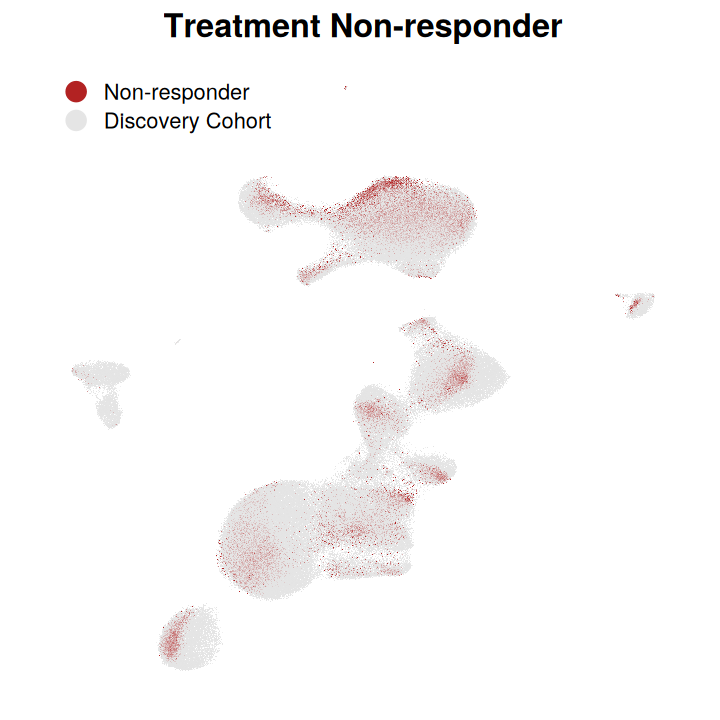

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- bind_rows(umap.discovery, umap.nonresponder) %>%
  mutate(cohort = factor(cohort, levels = c("Non-responder", "Discovery Cohort")))

plot <- embedding.plot(
  data,
  colour = "cohort",
  cmap = c("Non-responder" = "firebrick", "Discovery Cohort" = "grey90"),
  labs = list(title = "Treatment Non-responder", colour = NULL),
  show.legend = TRUE,
  shuffle = FALSE,
  rasterise = TRUE,
  size.adj = 2,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), ncol = 1)) +
  inset.legend(location = "topleft") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/cohort_nonresponder_all_donor_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

## Longitudinal T~c~1-TH comparison

In [ ]:
# Subset to T cells only
sub.discovery <- subset(ref, subset = cluster_main == "T")
sub.nonresponder <- subset(seu, subset = cluster_main == "T")
Idents(sub.discovery) <- "cluster_fine"
Idents(sub.nonresponder) <- "cluster_fine"

In [ ]:
sub.discovery[["GEP"]] <- CreateAssayObject(data = gep.usage.discovery[["T"]])
sub.nonresponder[["GEP"]] <- CreateAssayObject(data = gep.usage.nonresponder[["T"]][, colnames(sub.nonresponder)])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Warning message:
"Layer counts isn't present in the assay object; returning NULL"


In [ ]:
chosen.gep <- Features(sub.nonresponder[["GEP"]])[c(13, 20, 30)]
chosen.gep

[1] "Th1-like (CXCR3/CCL5/ITGA4)"             
[2] "Cytotoxic Inflammatory (GZMK/EOMES/IFNG)"
[3] "Activation Signalling (IER2/CD69/CD83)"

In [ ]:
sub.discovery$program_score <- apply(GetAssayData(sub.discovery, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)
sub.nonresponder$program_score <- apply(GetAssayData(sub.nonresponder, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

In [ ]:
data <- FetchData(sub.discovery, vars = c("donor", "hash_id", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = join_by(donor == donor_id)) %>%
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory")) %>%
  mutate(
    interval = case_match(
      hash_id,
      "1" ~ 0,
      "2" ~ infusion_2_interval,
      "3" ~ infusion_2_interval + infusion_3_interval,
      "4" ~ infusion_2_interval + infusion_3_interval + infusion_4_interval,
      "5" ~ infusion_2_interval + infusion_3_interval + infusion_4_interval + infusion_5_interval,
      .default = NA
    )
  )

data.summary.discovery <- data %>%
  group_by(donor, hash_id) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    interval = first(interval),
    .groups = "drop"
  )

In [ ]:
data <- FetchData(sub.nonresponder, vars = c("donor", "hash_id", "cluster_coarse", "program_score")) %>%
  mutate(donor = as.character(donor)) %>%
  left_join(donor.metadata, by = join_by(donor == donor_id)) %>%
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory")) %>%
  mutate(
    interval = case_match(
      hash_id,
      "1" ~ 0,
      "2" ~ infusion_2_interval,
      "3" ~ infusion_2_interval + infusion_3_interval,
      "4" ~ infusion_2_interval + infusion_3_interval + infusion_4_interval,
      "5" ~ infusion_2_interval + infusion_3_interval + infusion_4_interval + infusion_5_interval,
      .default = NA
    )
  )

data.summary.nonresponder <- data %>%
  group_by(donor, hash_id) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    interval = first(interval),
    .groups = "drop"
  )
data.summary.nonresponder[data.summary.nonresponder$hash_id == "Relapse", "interval"] <- interval(as_date("2023-03-07"), as_date("2025-06-10")) / days(1) # manually add date for relapse sample (not related to ocrelizumab infusion date)

In [ ]:
data.summary <- bind_rows(data.summary.nonresponder, data.summary.discovery) %>%
  mutate(
    cohort = case_when(
      !donor == "3530194" ~ "Discovery cohort",
      TRUE ~ donor
    )
  ) %>%
  arrange(desc(cohort))

In [ ]:
infusion_2_program_scores <- data.summary %>%
  filter(hash_id == "2") %>%
  select(donor, program_score) %>%
  pull(program_score, name = donor)

infusion_2_intervals <- data.summary %>%
  filter(hash_id == "2") %>%
  select(donor, interval) %>%
  pull(interval, name = donor)

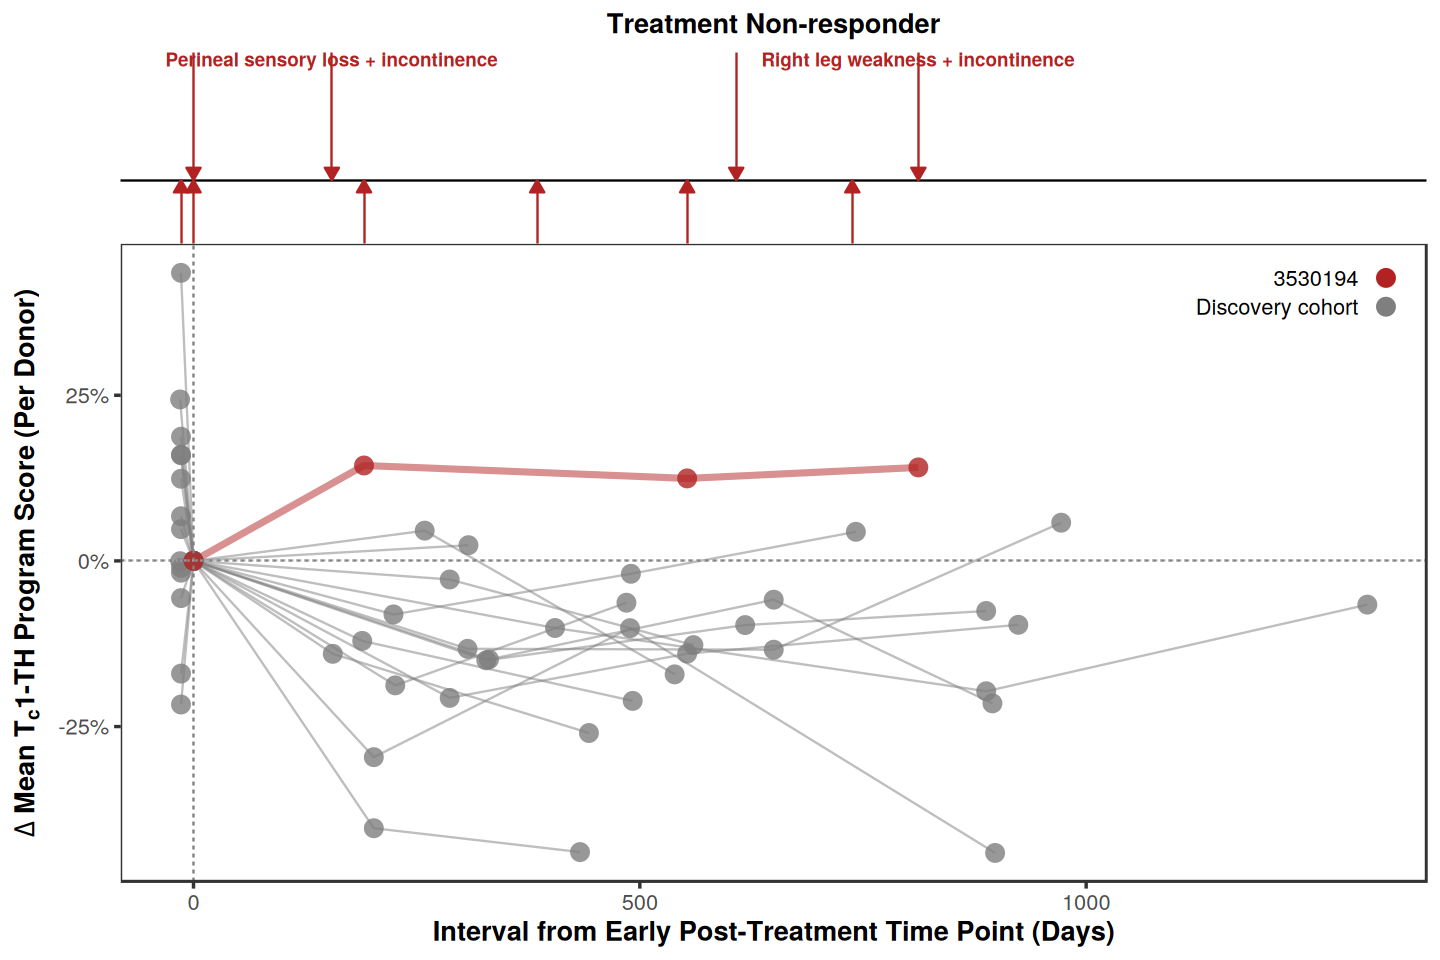

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

plot <- ggplot(
  data = data.summary %>%
    mutate(
      delta_program_score = (program_score - infusion_2_program_scores[donor]) / infusion_2_program_scores[donor],
      interval = interval - infusion_2_intervals[donor]
    ),
  mapping = aes(x = interval, y = delta_program_score, linewidth = cohort, colour = cohort, group = factor(donor, levels = rev(sort(unique(donor)))))
) +
  geom_line(alpha = 0.5, show.legend = FALSE) +
  geom_point(
    size = 5,
    shape = 16,
    alpha = 0.8,
    fill = "white"
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey50") +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey50") +
  geom_hline(yintercept = 0, linetype = "dotted", colour = "grey70") +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  scale_colour_manual(values = c("3530194" = "firebrick", "Discovery cohort" = "grey50")) +
  scale_linewidth_manual(values = c("3530194" = 1.5, "Discovery cohort" = 0.5)) +
  guides(colour = guide_legend(override.aes = list(size = 5, shape = 16, alpha = 1)), linewidth = guide_none()) +
  labs(title = "Treatment Non-responder", x = "Interval from Early Post-Treatment Time Point (Days)", y = expression(bold(Delta ~ Mean ~ T[c] * "1-" * TH ~ Program ~ Score ~ '(Per Donor)')), colour = NULL) +
  theme_custom() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold")
  ) +
  inset.legend(location = "topright")

# Manually annotated clinical events by date
marginal.x <- cowplot::axis_canvas(plot, axis = "x") +
  geom_hline(yintercept = 0) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2023-03-07")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2023-03-07")) / days(1),
    y = -0.5,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick"
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2023-03-21")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2023-03-21")) / days(1),
    y = -0.5,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick"
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2023-09-28")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2023-09-28")) / days(1),
    y = -0.5,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick"
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2024-04-09")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2024-04-09")) / days(1),
    y = -0.5,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick"
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2024-09-24")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2024-09-24")) / days(1),
    y = -0.5,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick"
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2025-03-28")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2025-03-28")) / days(1),
    y = -0.5,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick"
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2023-08-23")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2023-08-23")) / days(1),
    y = 1,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick"
  ) +
  annotate(
    geom = "text",
    x = interval(as_date("2023-03-21"), as_date("2023-08-23")) / days(1),
    y = 1,
    label = "Perineal sensory loss + incontinence",
    vjust = 1,
    colour = "firebrick",
    fontface = "bold"
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2023-03-21")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2023-03-21")) / days(1),
    y = 1,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick",
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2024-11-18")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2024-11-18")) / days(1),
    y = 1,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick",
  ) +
  annotate(
    geom = "segment",
    x = interval(as_date("2023-03-21"), as_date("2025-06-10")) / days(1),
    xend = interval(as_date("2023-03-21"), as_date("2025-06-10")) / days(1),
    y = 1,
    yend = 0,
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    colour = "firebrick",
  ) +
  annotate(
    geom = "text",
    x = interval(as_date("2023-03-21"), as_date("2025-06-10")) / days(1),
    y = 1,
    label = "Right leg weakness + incontinence",
    vjust = 1,
    colour = "firebrick",
    fontface = "bold"
  )

final.plot <- plot %>%
  cowplot::insert_xaxis_grob(marginal.x, position = "top", clip = "off", height = unit(0.3, "null"))

ggdraw(final.plot)

ggsave(
  plot = final.plot,
  filename = "../results/plots/cohort_nonresponder_tc1th_longitudinal_program_score.pdf",
  width = 12,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Session Info

In [ ]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] cowplot_1.1.3      patchwork_1.3.0    lubridate_1.9.3    forcats_1.0.0     
 [5] stringr_1.5.1      dplyr_1.1.4        purrr_1.0.2        readr_2.1.5       
 [9] tidyr_1.3.1        tibble_3.2.1       ggplot2_3.5.1      tidyverse_2.0.0   
[13] future_1.34.0      Seurat_5.1.0       SeuratObject_5.0.2 sp_2.1-4          

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_1.8.9         magrittr_2.0.3        
  [4] spatstat.utils_3.1-0   farver_2.1.2           vctrs_0.6.5           
  [7] ROCR_1.0-11            Cairo_1.6